# Exploratory Data Analysis (EDA)

## Objective
The goal of this notebook is to understand the distribution of the data,
discover relationships between variables, identify important features,
detect outliers, and generate business insights before model training.

In [118]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [119]:
df = pd.read_csv("../data/processed/cleaned_used_cars.csv")

In [120]:
df.shape

(37813, 72)

In [121]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 37813 entries, 0 to 37812
Data columns (total 72 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   position               37813 non-null  int64  
 1   model_year             37813 non-null  int64  
 2   body_type              37813 non-null  str    
 3   transmission           37813 non-null  str    
 4   fuel_type              37813 non-null  str    
 5   full_vehicle_name      37813 non-null  str    
 6   brand                  37813 non-null  str    
 7   model                  37813 non-null  str    
 8   vehicle_name           37813 non-null  str    
 9   centralVariantId       37813 non-null  int64  
 10  variantName            37813 non-null  str    
 11  city_x                 37813 non-null  str    
 12  price                  37813 non-null  int64  
 13  discountValue          37813 non-null  int64  
 14  msp                    37813 non-null  int64  
 15  utype        

In [122]:
df.head()

,position,model_year,body_type,transmission,fuel_type,full_vehicle_name,brand,model,vehicle_name,centralVariantId,...,body_type_new,owner_type_new,variant_name,price_segment,brand_new,variant_new,exterior_color,owner_type,price_segment_new,Fuel Suppy System
0,1,2016,Hatchback,Manual,CNG,Maruti Wagon R LXI CNG,Maruti,Maruti Wagon R,Maruti Wagon R LXI CNG,4312,...,Hatchback cars,first,maruti wagon r lxi cng,2lakh-5lakh,maruti,maruti wagon r lxi cng,Silver,first,2lakh-5lakh,MPFI
1,2,2015,Hatchback,Manual,CNG,Maruti Celerio Green VXI,Maruti,Maruti Celerio,Maruti Celerio Green VXI,3984,...,Hatchback cars,first,maruti celerio green vxi,2lakh-5lakh,maruti,maruti celerio green vxi,Grey,first,2lakh-5lakh,Intelligent-Gas Port Injection
2,3,2015,Sedan,Manual,CNG,Honda Amaze S Plus i-VTEC,Honda,Honda Amaze,Honda Amaze S Plus i-VTEC,1177,...,Sedan cars,second,honda amaze s plus i-vtec,2lakh-5lakh,honda,honda amaze s plus i-vtec,Silver,second,2lakh-5lakh,MPFI
3,4,2013,Hatchback,Manual,CNG,Maruti Wagon R LXI CNG,Maruti,Maruti Wagon R,Maruti Wagon R LXI CNG,4351,...,Hatchback cars,second,maruti wagon r lxi cng,2lakh-5lakh,maruti,maruti wagon r lxi cng,Silver,second,2lakh-5lakh,MPFI
4,5,2022,MUV,Manual,CNG,Maruti Ertiga VXI CNG,Maruti,Maruti Ertiga,Maruti Ertiga VXI CNG,8957,...,MUV cars,first,maruti ertiga vxi cng,10+lakh,maruti,maruti ertiga vxi cng,White,first,10+lakh,MPFI


In [123]:
df.describe()

,position,model_year,centralVariantId,price,discountValue,msp,Displacement,Max Power,Max Torque,No of Cylinder,Values per Cylinder,Length,Width,Height,Wheel Base,Seating Capacity,No Door Numbers,km_driven,used_carid
count,37813.000000,37813.000000,37813.000000,3.781300e+04,37813.000000,3.781300e+04,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,3.781300e+04,3.781300e+04
mean,12.786528,2015.569460,4244.421786,7.854508e+05,73.281702,5.426705e+01,1438.369767,102.667226,178.565484,3.820088,3.894639,4073.186655,1709.861556,1562.437707,2502.459339,5.236612,4.664480,6.240901e+04,3.350111e+06
std,4.538552,3.779097,2456.179185,1.132718e+06,2805.783272,7.477564e+03,470.289774,42.667988,106.060102,0.540516,0.477025,555.307512,207.482666,188.306065,361.008026,0.722096,0.496371,5.847222e+04,4.822133e+04
min,1.000000,1983.000000,3.000000,1.196300e+04,0.000000,0.000000e+00,0.000000,10.800000,4.800000,1.000000,1.000000,3.000000,1.000000,1.000000,2.000000,0.000000,2.000000,1.010000e+02,2.123741e+06
25%,9.000000,2013.000000,1689.000000,3.200000e+05,0.000000,0.000000e+00,1197.000000,75.000000,110.000000,4.000000,4.000000,3780.000000,1677.000000,1495.000000,2425.000000,5.000000,4.000000,3.173900e+04,3.323256e+06
50%,13.000000,2016.000000,4191.000000,5.250000e+05,0.000000,0.000000e+00,1248.000000,88.500000,145.000000,4.000000,4.000000,3995.000000,1710.000000,1530.000000,2520.000000,5.000000,5.000000,5.672600e+04,3.366215e+06
75%,17.000000,2018.000000,6373.000000,8.550000e+05,0.000000,0.000000e+00,1582.000000,118.350000,220.000000,4.000000,4.000000,4430.000000,1790.000000,1640.000000,2636.000000,5.000000,5.000000,8.331000e+04,3.384768e+06
max,20.000000,2023.000000,9670.000000,9.551953e+07,200000.000000,1.093000e+06,6749.000000,769.310000,900.000000,16.000000,48.000000,5982.000000,2236.000000,2075.000000,3772.000000,14.000000,6.000000,6.300000e+06,3.399050e+06


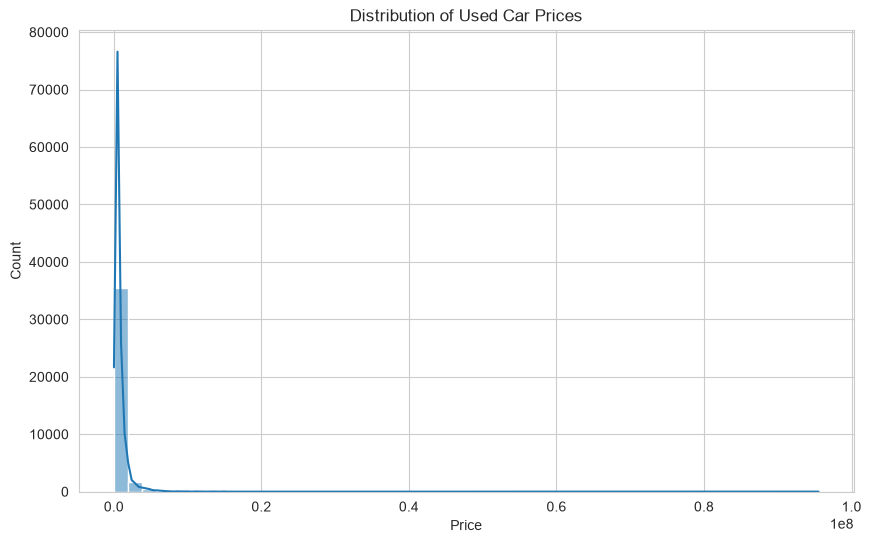

In [124]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="price",
    bins=50,
    kde=True
)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [125]:
df["price"].describe()

count    3.781300e+04
mean     7.854508e+05
std      1.132718e+06
min      1.196300e+04
25%      3.200000e+05
50%      5.250000e+05
75%      8.550000e+05
max      9.551953e+07
Name: price, dtype: float64

In [126]:
df["price"].skew()

np.float64(22.230988655489238)

### Insight 1: Distribution of Used Car Prices

- The distribution of used car prices is highly positively skewed.
- Most used cars are priced below ₹10 lakh.
- A small number of luxury vehicles create a long right tail.
- The mean price (₹7.85 lakh) is considerably higher than the median (₹5.25 lakh), confirming the effect of expensive outliers.
- The target variable has a skewness of 22.23, indicating an extremely right-skewed distribution.

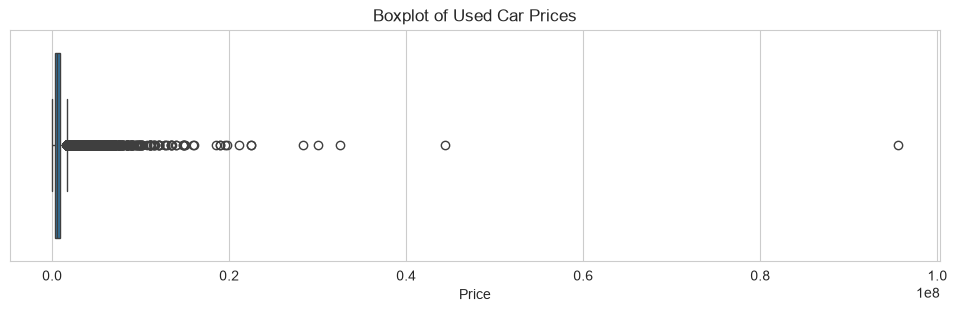

In [127]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=df["price"]
)

plt.title("Boxplot of Used Car Prices")
plt.xlabel("Price")

plt.show()

### Insight 2: Outlier Analysis of Used Car Prices



- The boxplot reveals a large number of outliers on the higher price side.

- These outliers correspond to genuine luxury and premium vehicles rather than data errors.

- Very few lower-end outliers are present, indicating a natural lower price bound in the used car market.

- The compact box and long upper tail further confirm that the target variable is highly right-skewed.

- These observations suggest that the expensive vehicles should be retained, as they represent valid market data.

In [128]:
df["brand"].value_counts()

brand
Maruti                9951
Hyundai               7418
Honda                 3908
Mahindra              2135
Tata                  2026
Toyota                1239
Ford                  1185
Renault               1180
Volkswagen            1062
Skoda                 1020
Mercedes-Benz          924
Chevrolet              868
BMW                    775
Kia                    729
Audi                   664
Nissan                 653
MG                     423
Jeep                   364
Datsun                 357
Fiat                   255
Volvo                  133
Land Rover             131
Jaguar                 114
Mitsubishi              85
Mahindra Ssangyong      51
Isuzu                   31
Mini                    29
Porsche                 27
Mahindra Renault        23
Force                   11
Lexus                    8
Citroen                  7
Hindustan Motors         4
Bajaj                    3
ICML                     3
Lamborghini              3
Bentley               

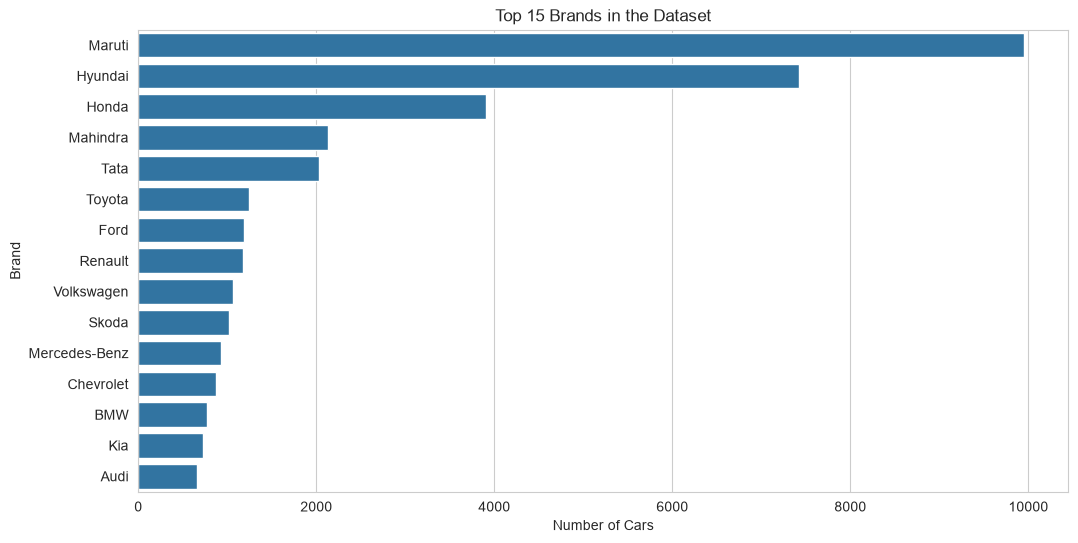

In [129]:
plt.figure(figsize=(12,6))

top_brands = df["brand"].value_counts().head(15)

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.title("Top 15 Brands in the Dataset")
plt.xlabel("Number of Cars")
plt.ylabel("Brand")

plt.show()

### Insight 3: Brand Distribution

- Maruti is the most represented brand with nearly 10,000 listings.
- Hyundai and Honda are the second and third most common brands.
- The dataset is dominated by mass-market manufacturers such as Maruti, Hyundai, Honda, Tata and Mahindra.
- Luxury brands like Rolls-Royce, Ferrari, Bentley and Lamborghini appear only a few times.
- The dataset is therefore highly imbalanced with respect to brand frequency.
- Rare luxury brands may not provide sufficient examples for the model to learn reliable pricing patterns.

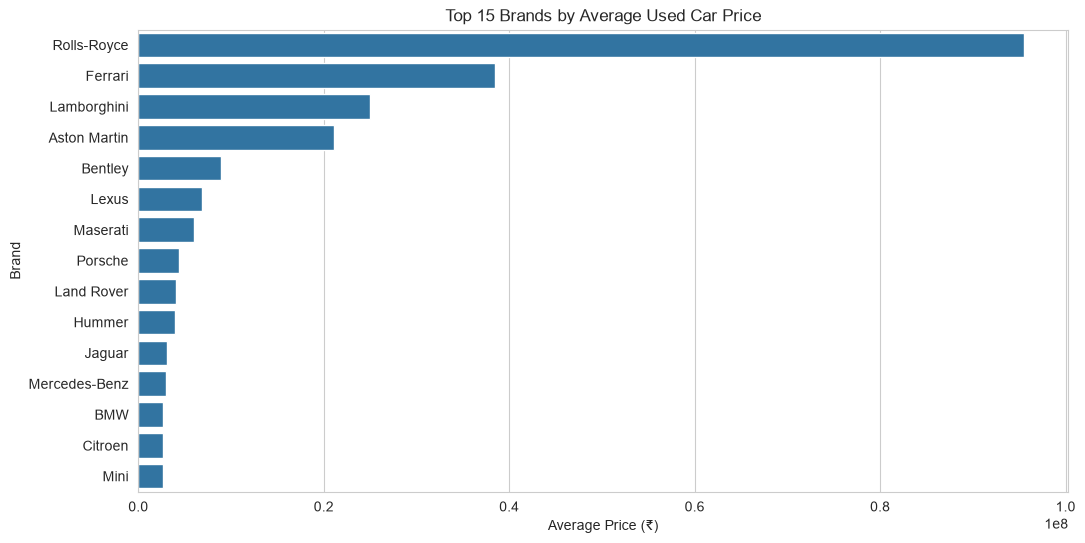

In [130]:
brand_price = (
    df.groupby("brand")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
      .reset_index()
)

brand_price
df.groupby("brand")["price"].mean()

plt.figure(figsize=(12,6))

sns.barplot(
    data=brand_price,
    x="price",
    y="brand"
)

plt.title("Top 15 Brands by Average Used Car Price")
plt.xlabel("Average Price (₹)")
plt.ylabel("Brand")

plt.show()

In [131]:
brand_price_filtered = (
    df.groupby("brand")
      .agg(
          Average_Price=("price", "mean"),
          Count=("price", "count")
      )
)

brand_price_filtered = (
    brand_price_filtered
    [brand_price_filtered["Count"] >= 100]
    .sort_values("Average_Price", ascending=False)
    .head(15)
)

brand_price_filtered




,Average_Price,Count
brand,,
Land Rover,4.115622e+06,131
Jaguar,3.040002e+06,114
Mercedes-Benz,3.019673e+06,924
BMW,2.710019e+06,775
Volvo,2.547750e+06,133
Audi,2.058113e+06,664
MG,1.780387e+06,423
Jeep,1.688137e+06,364
Kia,1.419410e+06,729


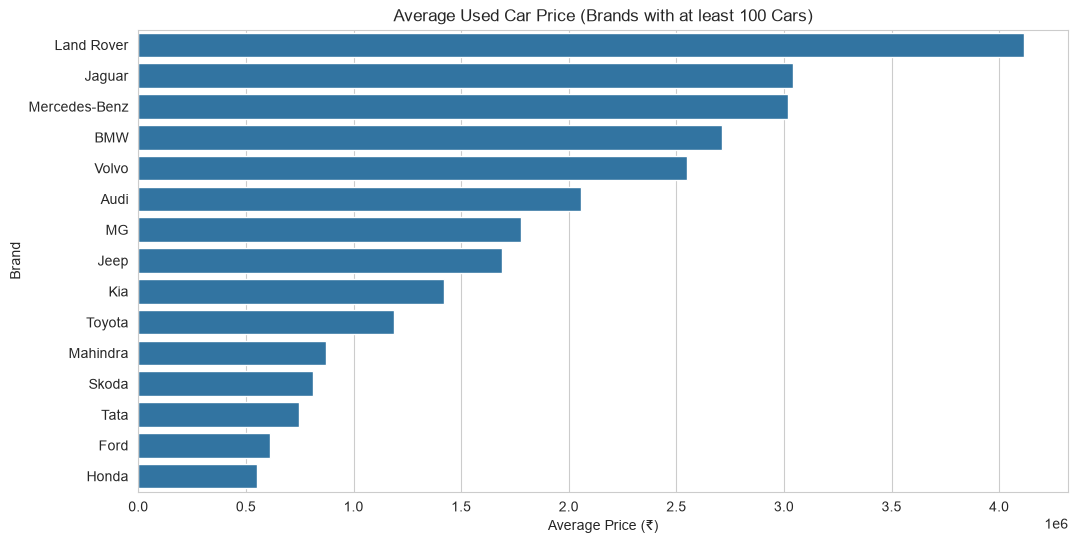

In [132]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=brand_price_filtered.reset_index(),
    x="Average_Price",
    y="brand"
)

plt.title("Average Used Car Price (Brands with at least 100 Cars)")
plt.xlabel("Average Price (₹)")
plt.ylabel("Brand")

plt.show()

### Insight 4: Average Used Car Price by Brand

- After filtering brands with fewer than 100 listings, premium brands such as Land Rover, Jaguar, Mercedes-Benz, BMW and Volvo have the highest average used-car prices.
- The previous analysis containing Rolls-Royce and Ferrari was influenced by extremely small sample sizes and was therefore less reliable.
- Luxury and premium manufacturers consistently command higher resale prices.
- Mass-market brands such as Honda, Ford, Tata and Mahindra have considerably lower average resale values.
- Brand is likely to be one of the most influential predictors of used car price.

In [133]:
df["fuel_type"].value_counts()

fuel_type
Petrol      21773
Diesel      14629
CNG          1076
LPG           205
Electric      130
Name: count, dtype: int64

In [134]:
fuel_percent = (
    df["fuel_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

fuel_percent

fuel_type
Petrol      57.58
Diesel      38.69
CNG          2.85
LPG          0.54
Electric     0.34
Name: proportion, dtype: float64

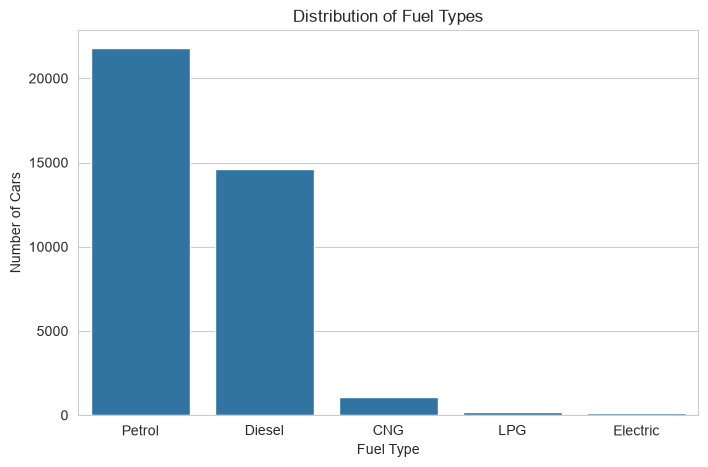

In [135]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="fuel_type",
    order=df["fuel_type"].value_counts().index
)

plt.title("Distribution of Fuel Types")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.show()

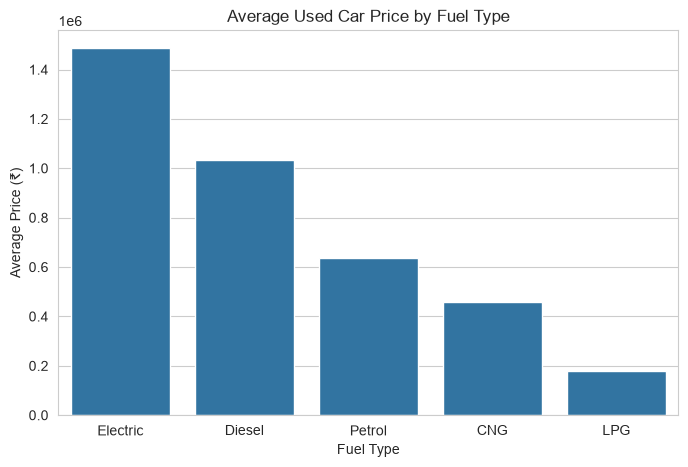

In [136]:
fuel_price = (
    df.groupby("fuel_type")
      .agg(
          Average_Price=("price", "mean"),
          Count=("price", "count")
      )
      .sort_values("Average_Price", ascending=False)
      .reset_index()
)

fuel_price

plt.figure(figsize=(8,5))

sns.barplot(
    data=fuel_price,
    x="fuel_type",
    y="Average_Price"
)

plt.title("Average Used Car Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price (₹)")

plt.show()

### Insight 6: Average Used Car Price by Fuel Type

- Electric vehicles have the highest average resale price, followed by Diesel and Petrol vehicles.
- The higher average price of Electric vehicles is expected because most electric cars in the dataset belong to premium or mid-premium segments.
- Diesel vehicles also have a higher average resale price than Petrol vehicles, likely due to their popularity in larger SUVs and premium cars.
- LPG vehicles have the lowest average resale price.
- Fuel type appears to influence resale value and is likely to be an important feature for price prediction.

In [137]:
df["model_year"].describe()

count    37813.000000
mean      2015.569460
std          3.779097
min       1983.000000
25%       2013.000000
50%       2016.000000
75%       2018.000000
max       2023.000000
Name: model_year, dtype: float64

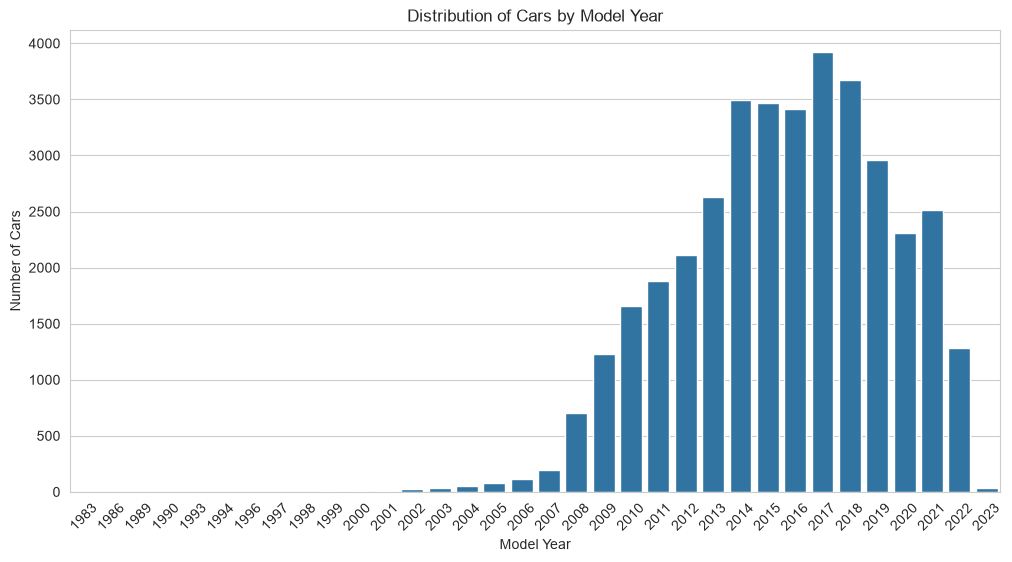

In [138]:
year_counts = (
    df["model_year"]
    .value_counts()
    .sort_index()
)

year_counts

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="model_year",
    order=sorted(df["model_year"].unique())
)

plt.title("Distribution of Cars by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45)

plt.show()

### Insight 7: Distribution of Model Years

- The dataset mainly consists of cars manufactured between **2013 and 2021**.
- The highest number of used car listings belongs to the **2017–2018** model years.
- Very few cars are older than 2005, indicating that vintage vehicles form only a small portion of the dataset.
- Listings decrease for **2022–2023** because newer cars are less likely to appear in the used car market.
- The mean model year (2015.57) is very close to the median (2016), indicating a fairly balanced distribution without significant skewness.

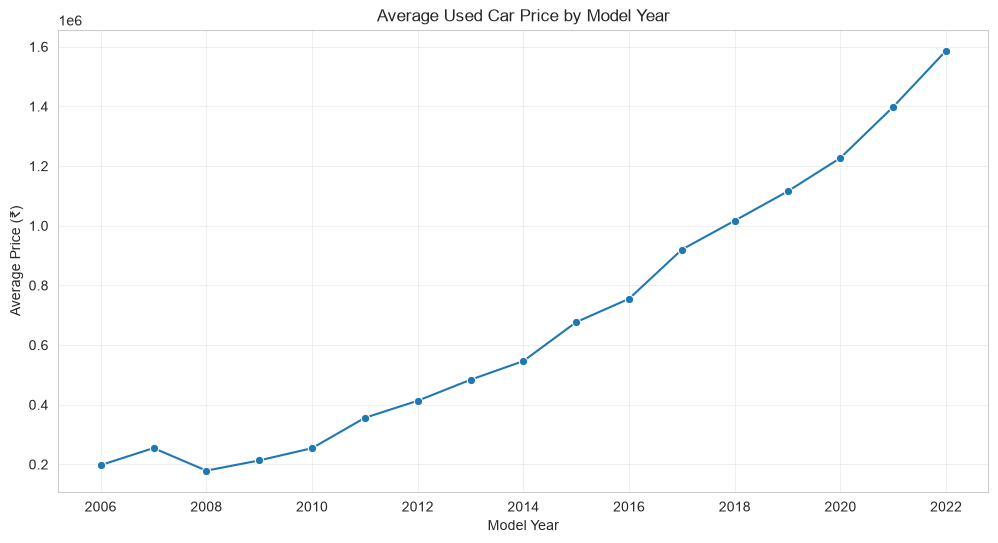

In [139]:
year_counts = df["model_year"].value_counts()

valid_years = year_counts[year_counts >= 100].index

year_price = (
    df[df["model_year"].isin(valid_years)]
      .groupby("model_year")["price"]
      .mean()
      .reset_index()
)
plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_price,
    x="model_year",
    y="price",
    marker="o"
)

plt.title("Average Used Car Price by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Average Price (₹)")

plt.grid(alpha=0.3)

plt.show()

In [140]:
df["model_year"].value_counts().sort_index()

model_year
1983       1
1986       1
1989       1
1990       1
1993       1
1994       1
1996       2
1997       2
1998       2
1999       4
2000      10
2001      11
2002      24
2003      31
2004      54
2005      78
2006     119
2007     199
2008     699
2009    1226
2010    1654
2011    1879
2012    2108
2013    2633
2014    3491
2015    3467
2016    3418
2017    3924
2018    3675
2019    2960
2020    2304
2021    2516
2022    1282
2023      35
Name: count, dtype: int64

### Insight 8: Average Used Car Price by Model Year

- Average used car prices generally increase with newer model years.
- Cars manufactured after 2015 show a sharp increase in average resale price.
- This indicates that newer vehicles retain higher market value because of lower depreciation and updated features.
- Model year is expected to be one of the strongest predictors of used car price.
- The unusually high average price for 2023 models should be interpreted carefully because only **35 cars** from 2023 are present in the dataset, making the average sensitive to a few premium vehicles.

In [141]:
df["km_driven"].describe()

count    3.781300e+04
mean     6.240901e+04
std      5.847222e+04
min      1.010000e+02
25%      3.173900e+04
50%      5.672600e+04
75%      8.331000e+04
max      6.300000e+06
Name: km_driven, dtype: float64

In [142]:
df["km_driven"].skew()

np.float64(45.19835153070059)

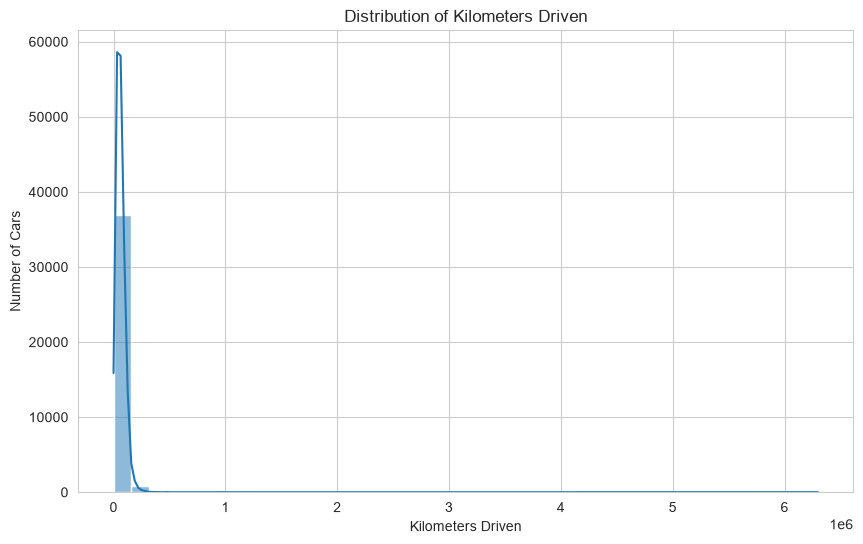

In [143]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["km_driven"],
    bins=40,
    kde=True
)

plt.title("Distribution of Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Number of Cars")

plt.show()

### Insight 9: Distribution of Kilometers Driven

- Most used cars have been driven less than **1 lakh kilometers**.
- The distribution is highly positively skewed with a long right tail.
- The mean mileage (62,409 km) is slightly higher than the median (56,726 km), indicating the influence of high-mileage vehicles.
- The dataset contains extremely high mileage values (maximum 6.3 million km), which are likely data-entry or scraping errors and should be investigated before model training.

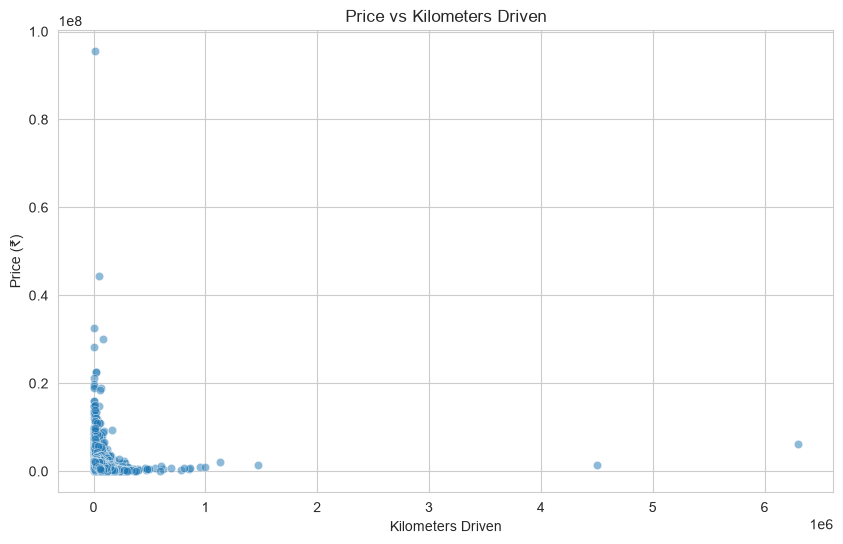

In [144]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="km_driven",
    y="price",
    alpha=0.5
)

plt.title("Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Price (₹)")

plt.show()

In [145]:
df.nlargest(10, "km_driven")[
    ["brand","model","model_year","km_driven","price"]
]

,brand,model,model_year,km_driven,price
8052,Mercedes-Benz,Mercedes-Benz GLS,2018,6300000,6300000
17082,Mahindra,Mahindra Bolero,2006,4500088,1500000
29162,Honda,Honda City,2020,1466000,1417000
7502,Mercedes-Benz,Mercedes-Benz M-Class,2014,1130000,2190000
35898,Mahindra,Mahindra XUV500,2016,995000,995000
4186,Renault,Renault Duster,2016,954000,922000
25912,Honda,Honda City,2015,859000,811000
4390,Ford,Ford Ecosport,2017,853883,500000
37236,Hyundai,Hyundai i20,2017,810338,771500
14261,Honda,Honda Brio,2014,780000,375000


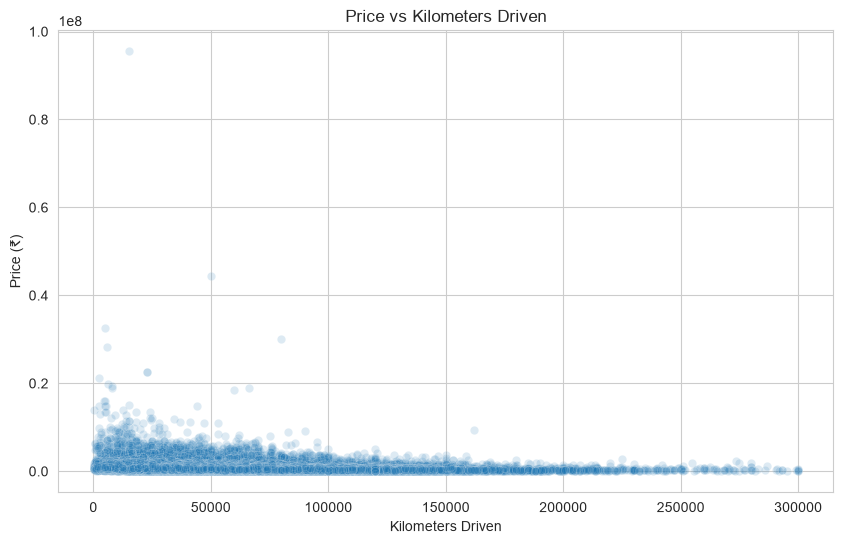

In [146]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=filtered_df,
    x="km_driven",
    y="price",
    alpha=0.15
)

plt.title("Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Price (₹)")

plt.show()

In [147]:
df[["km_driven", "price"]].corr()

,km_driven,price
km_driven,1.000000,-0.115244
price,-0.115244,1.000000


### Insight 10: Average Used Car Price by Model Year

- The average resale price generally increases with newer model years.
- Cars manufactured after 2013 show a steady rise in average price, reflecting lower depreciation and newer technology.
- The highest average price is observed for the latest model year (2023), but this value should be interpreted cautiously because very few 2023 cars are present in the dataset.
- Older model years (before 2008) have very few observations, causing fluctuations in their average prices.
- Overall, model year is one of the strongest indicators of resale value and is expected to be an important feature during model training.

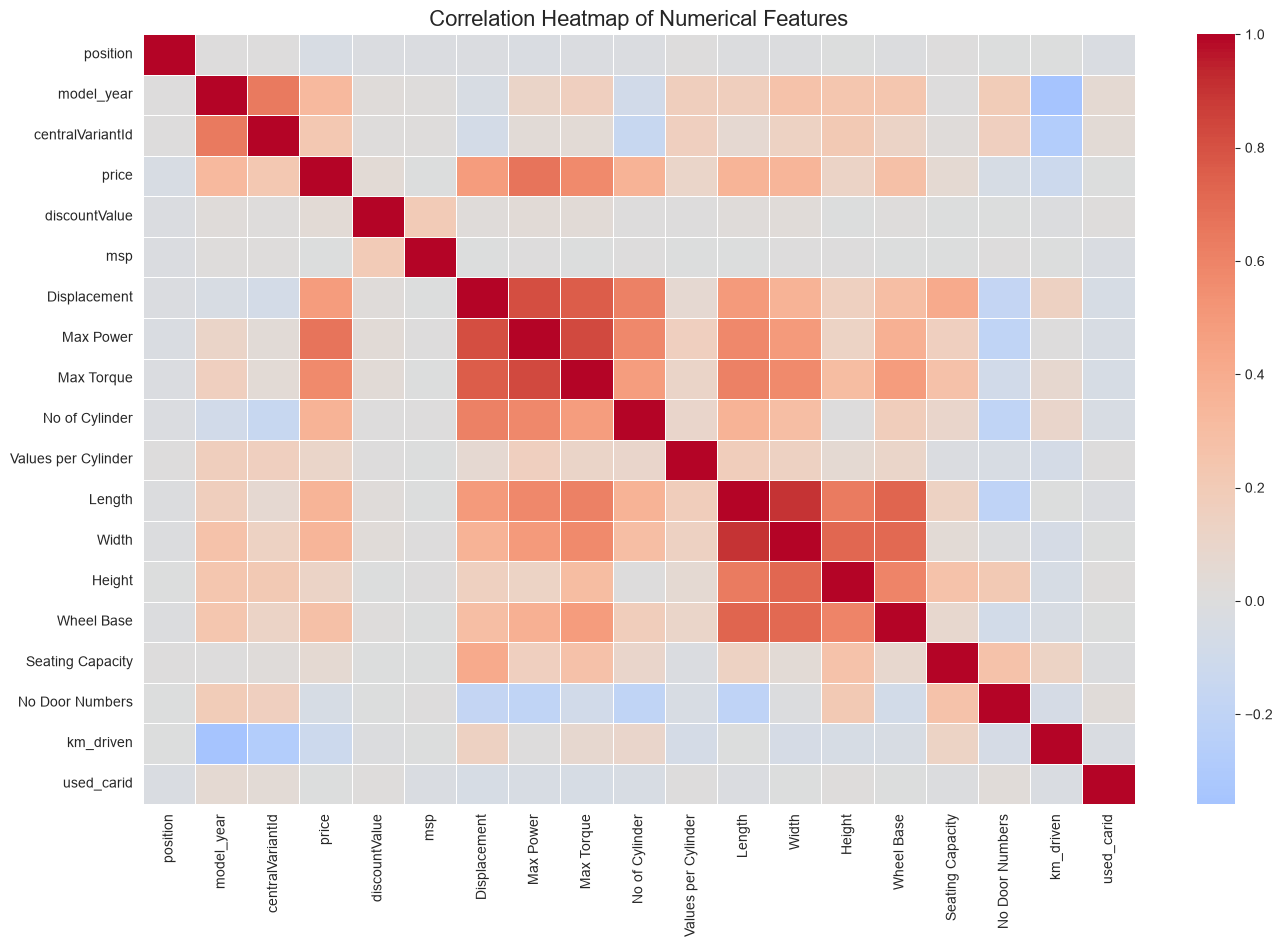

In [148]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

numeric_df.columns

corr_matrix = numeric_df.corr()

corr_matrix


plt.figure(figsize=(16,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.show()

In [149]:
price_corr = (
    corr_matrix["price"]
    .sort_values(ascending=False)
)

price_corr

price                  1.000000
Max Power              0.669222
Max Torque             0.572780
Displacement           0.486714
No of Cylinder         0.364861
Length                 0.354927
Width                  0.350242
model_year             0.323676
Wheel Base             0.276671
centralVariantId       0.221283
Height                 0.120354
Values per Cylinder    0.103941
Seating Capacity       0.064290
discountValue          0.041512
msp                    0.001069
used_carid            -0.002316
position              -0.041915
No Door Numbers       -0.048706
km_driven             -0.115244
Name: price, dtype: float64

### Insight 12: Correlation of Numerical Features with Price

- Max Power shows the strongest positive correlation with price (0.669), making it the most influential numerical feature.
- Engine-related attributes such as Max Torque, Displacement, and Number of Cylinders also exhibit moderate to strong positive correlations with resale price.
- Vehicle dimensions (Length, Width, and Wheel Base) have moderate positive relationships with price, indicating that larger vehicles generally cost more.
- Model Year has a positive correlation with price, confirming that newer vehicles retain higher resale values.
- No individual numerical feature has an extremely high correlation with price, suggesting that accurate price prediction will require combining multiple vehicle characteristics rather than relying on a single feature.

In [150]:
df["transmission"].value_counts()

transmission
Manual       28894
Automatic     8919
Name: count, dtype: int64

In [151]:
transmission_percent = (
    df["transmission"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

transmission_percent

transmission
Manual       76.41
Automatic    23.59
Name: proportion, dtype: float64

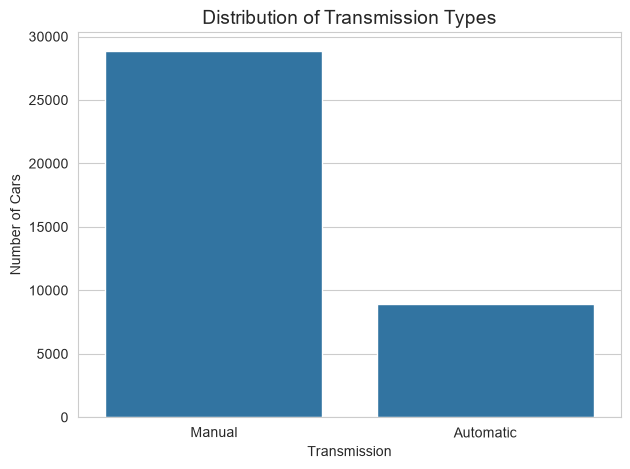

In [152]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="transmission",
    order=df["transmission"].value_counts().index
)

plt.title("Distribution of Transmission Types", fontsize=14)
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")

plt.show()

In [153]:
transmission_price = (
    df.groupby("transmission")["price"]
      .mean()
      .sort_values(ascending=False)
)

transmission_price

transmission
Automatic    1.633057e+06
Manual       5.238118e+05
Name: price, dtype: float64

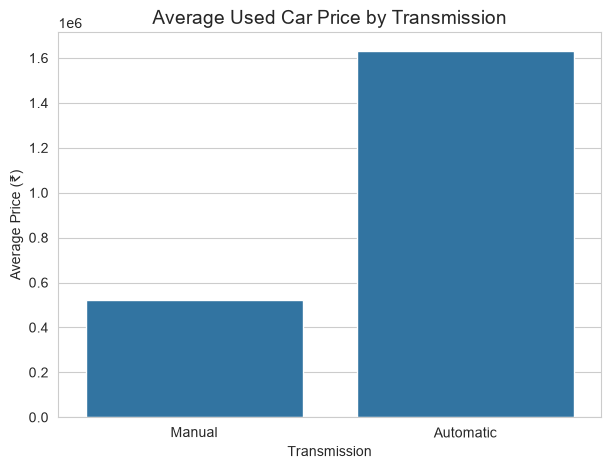

In [154]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="transmission",
    y="price",
    estimator="mean",
    errorbar=None
)

plt.title("Average Used Car Price by Transmission", fontsize=14)
plt.xlabel("Transmission")
plt.ylabel("Average Price (₹)")

plt.show()

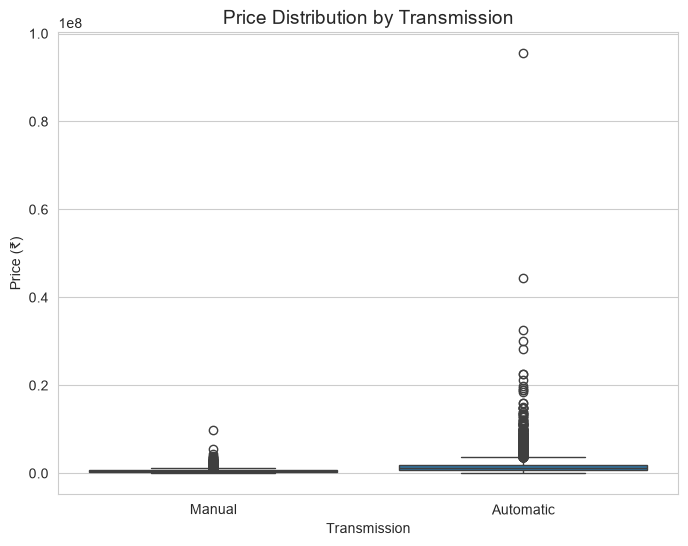

In [155]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="transmission",
    y="price"
)

plt.title("Price Distribution by Transmission", fontsize=14)
plt.xlabel("Transmission")
plt.ylabel("Price (₹)")

plt.show()

### Insight 13: Transmission Type Analysis

- Manual transmission vehicles dominate the dataset, accounting for 76.41% of all used cars, while automatic vehicles represent 23.59%.
- Automatic cars have a significantly higher average resale price (₹16.33 lakh) compared to manual cars (₹5.24 lakh).
- The boxplot shows that automatic vehicles have a higher median price and a wider spread of prices, indicating greater price variability.
- Automatic transmission is more common among premium and luxury vehicles, contributing to its substantially higher average resale value.
- Transmission type is therefore expected to be an important categorical feature for predicting used car prices.

In [156]:
df["body_type"].value_counts()

body_type
Hatchback          15073
Sedan              10543
SUV                 9817
MUV                 1816
Minivans             391
Luxury Vehicles       72
Pickup Trucks         47
Convertibles          22
Coupe                 21
Wagon                  7
Hybrids                4
Name: count, dtype: int64

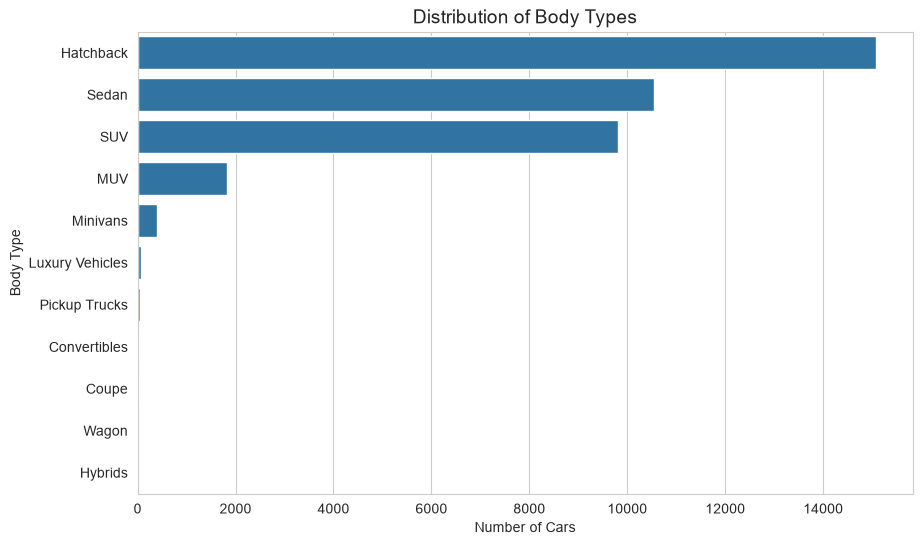

In [157]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="body_type",
    order=df["body_type"].value_counts().index
)

plt.title("Distribution of Body Types", fontsize=14)
plt.xlabel("Number of Cars")
plt.ylabel("Body Type")

plt.show()

In [158]:
body_price = (
    df.groupby("body_type")["price"]
      .agg(["mean", "count"])
      .rename(columns={"mean":"Average_Price",
                       "count":"Count"})
)

body_price

,Average_Price,Count
body_type,,
Convertibles,5.018365e+06,22
Coupe,1.175984e+07,21
Hatchback,3.889647e+05,15073
Hybrids,5.400000e+06,4
Luxury Vehicles,2.085630e+06,72
MUV,9.052300e+05,1816
Minivans,3.306087e+05,391
Pickup Trucks,9.438318e+05,47
SUV,1.294046e+06,9817


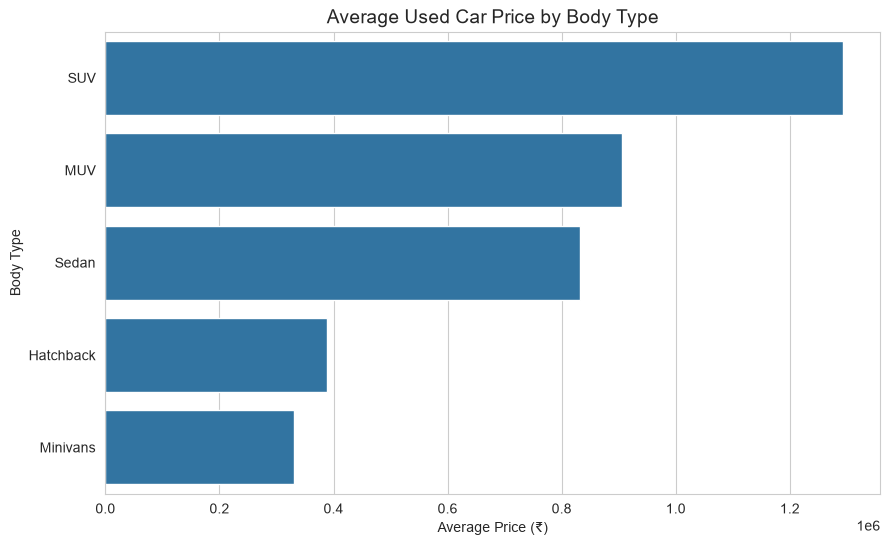

In [159]:
body_price_filtered = (
    body_price[body_price["Count"] >= 100]
    .sort_values("Average_Price", ascending=False)
)

body_price_filtered

plt.figure(figsize=(10,6))

sns.barplot(
    data=body_price_filtered.reset_index(),
    x="Average_Price",
    y="body_type",
    errorbar=None
)

plt.title("Average Used Car Price by Body Type", fontsize=14)
plt.xlabel("Average Price (₹)")
plt.ylabel("Body Type")

plt.show()

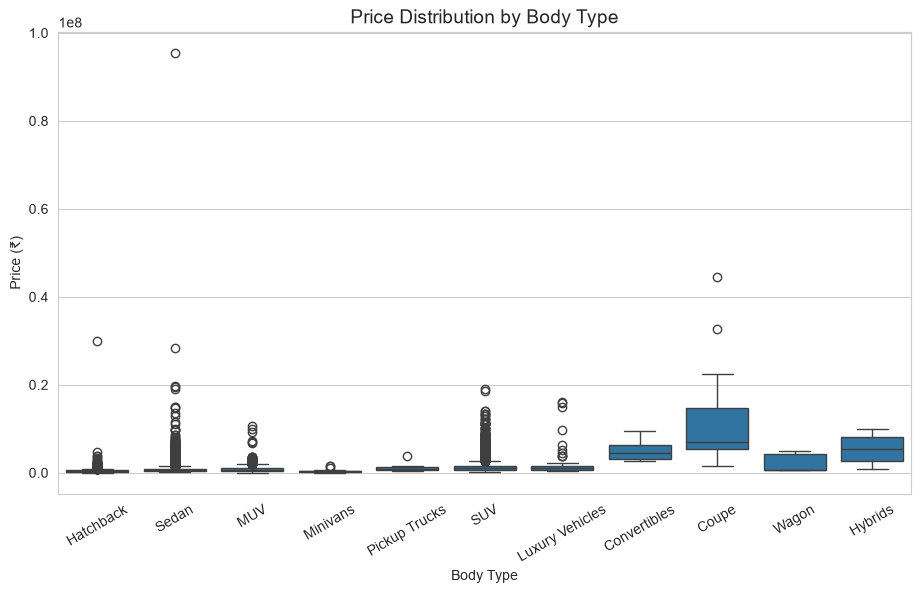

In [160]:
plt.figure(figsize=(11,6))

sns.boxplot(
    data=df,
    x="body_type",
    y="price"
)

plt.xticks(rotation=30)
plt.title("Price Distribution by Body Type", fontsize=14)
plt.xlabel("Body Type")
plt.ylabel("Price (₹)")

plt.show()

### Insight 14: Distribution of Body Types

- Hatchbacks are the most common body type in the dataset.
- Sedans and SUVs also constitute a significant share of used cars.
- MUVs are less common, while luxury body types such as Convertibles and Coupes appear only rarely.
- The dataset primarily represents mass-market passenger vehicles.

In [161]:
df["owner_type"].value_counts()

owner_type
first               26570
second               8768
third                1963
fourth                445
fifth                  58
unregistered car        9
Name: count, dtype: int64

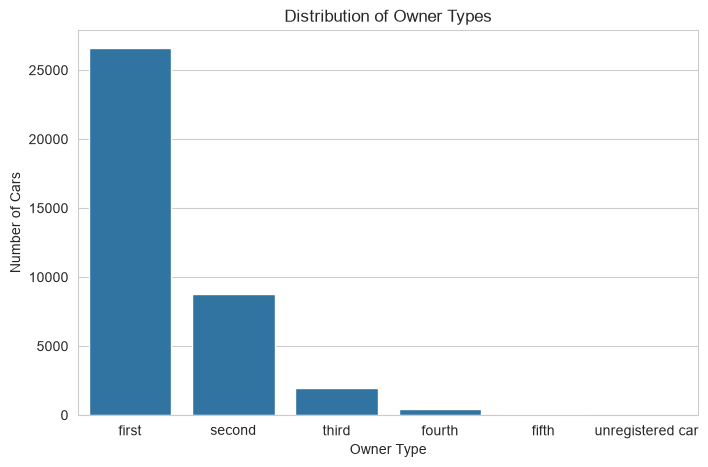

In [162]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="owner_type",
    order=df["owner_type"].value_counts().index
)

plt.title("Distribution of Owner Types")
plt.xlabel("Owner Type")
plt.ylabel("Number of Cars")

plt.show()

In [163]:
owner_price = (
    df.groupby("owner_type")["price"]
      .agg(["mean","count"])
      .rename(columns={
          "mean":"Average_Price",
          "count":"Count"
      })
      .sort_values("Average_Price", ascending=False)
)

owner_price

,Average_Price,Count
owner_type,,
unregistered car,1.082222e+06,9
first,8.703525e+05,26570
second,6.331063e+05,8768
third,4.336620e+05,1963
fifth,4.173311e+05,58
fourth,3.116513e+05,445


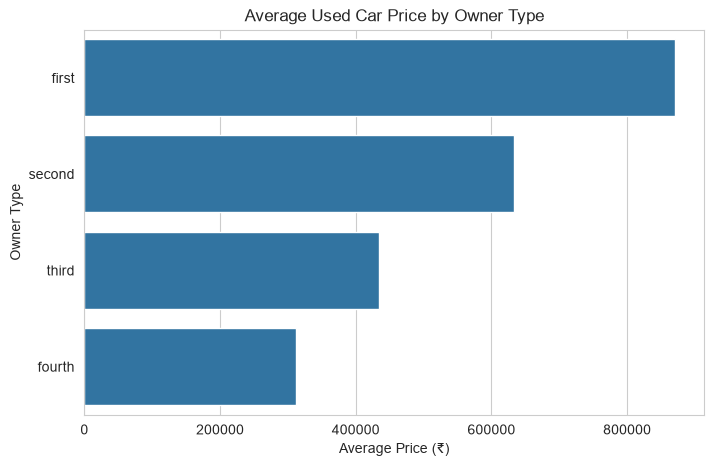

In [164]:
owner_price_filtered = owner_price[
    owner_price["Count"] >= 100
]

plt.figure(figsize=(8,5))

sns.barplot(
    data=owner_price_filtered.reset_index(),
    x="Average_Price",
    y="owner_type"
)

plt.title("Average Used Car Price by Owner Type")
plt.xlabel("Average Price (₹)")
plt.ylabel("Owner Type")

plt.show()

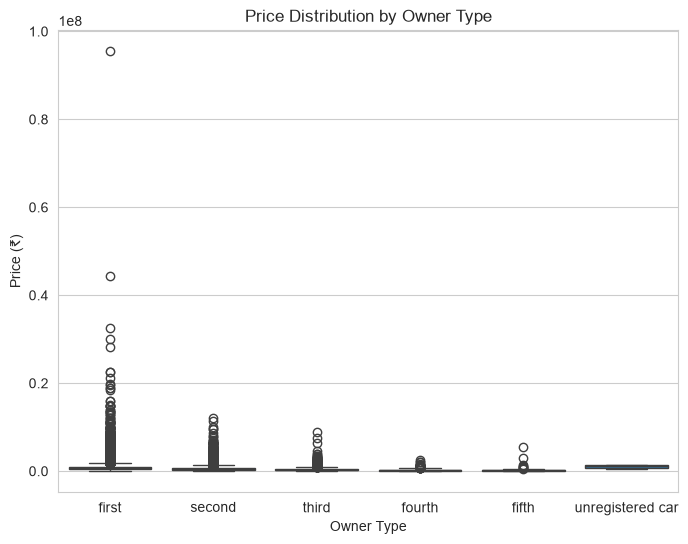

In [165]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="owner_type",
    y="price"
)

plt.title("Price Distribution by Owner Type")
plt.xlabel("Owner Type")
plt.ylabel("Price (₹)")

plt.show()

### Insight 17: Owner Type vs Price

- Around 70% of the cars in the dataset are first-owner vehicles.
- The average resale price decreases consistently as the number of previous owners increases.
- First-owner vehicles command the highest resale value, while third- and fourth-owner cars are significantly cheaper.
- Premium-priced vehicles are predominantly first-owner cars, indicating higher buyer trust and better vehicle condition.

In [166]:
df["city_x"].value_counts().head(15)

city_x
New Delhi     4969
Bangalore     4881
Pune          4821
Gurgaon       3235
Mumbai        2856
Hyderabad     1298
Noida         1214
Ahmedabad     1206
Kolkata       1159
Ghaziabad      940
Jaipur         937
Lucknow        920
Chennai        879
Surat          848
Chandigarh     695
Name: count, dtype: int64

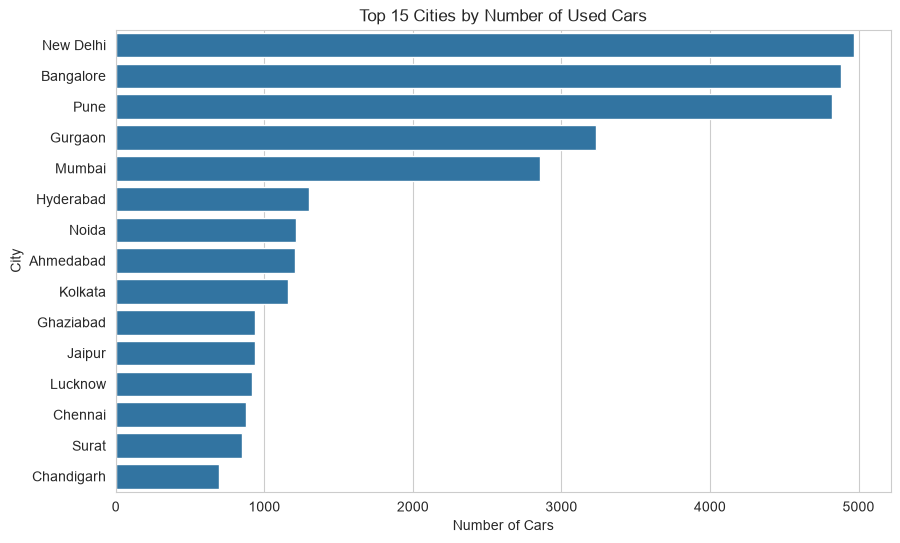

In [167]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="city_x",
    order=df["city_x"].value_counts().head(15).index
)

plt.title("Top 15 Cities by Number of Used Cars")
plt.xlabel("Number of Cars")
plt.ylabel("City")

plt.show()

### Insight 18: Distribution of Used Cars Across Cities

- New Delhi has the highest number of used car listings in the dataset.
- Bangalore and Pune closely follow, with nearly equal numbers of listings.
- Metropolitan cities dominate the dataset, reflecting higher vehicle ownership and stronger online used-car markets.
- The dataset provides good representation of major urban automobile markets in India.

In [168]:
city_price = (
    df.groupby("city_x")["price"]
      .agg(["mean","count"])
      .rename(columns={
          "mean":"Average_Price",
          "count":"Count"
      })
      .sort_values("Average_Price", ascending=False)
)

city_price.head(20)

,Average_Price,Count
city_x,,
jaunpur,1.035000e+07,3
Alwar,6.525000e+06,7
Bhawanipatna,5.500000e+06,1
Nimbahera,3.875000e+06,1
Poonamallee,3.100000e+06,1
Narsinghpur,3.100000e+06,1
Amritsar,3.013569e+06,44
Umbergaon,2.675000e+06,1
Ernakulam,2.662857e+06,7


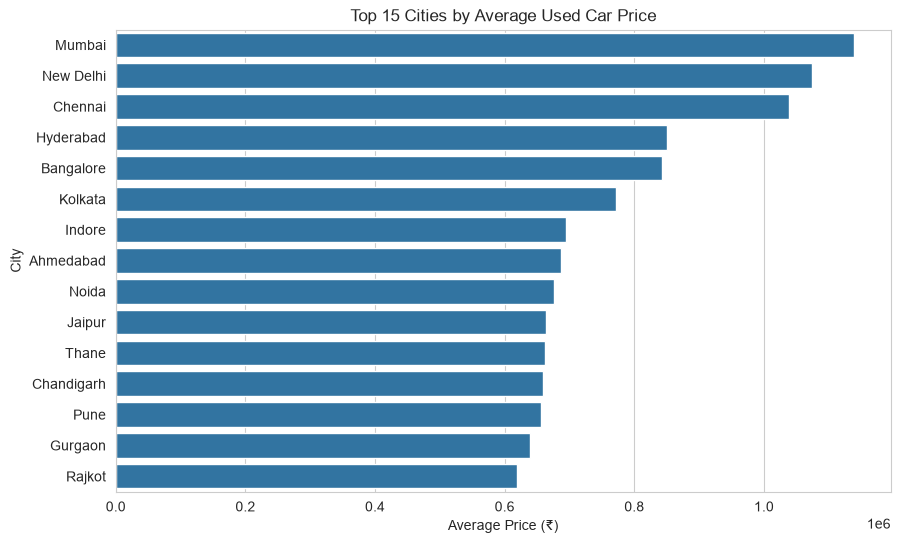

In [169]:
city_price_filtered = city_price[
    city_price["Count"] >= 200
]

city_price_filtered = city_price_filtered.sort_values(
    "Average_Price",
    ascending=False
)

city_price_filtered.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=city_price_filtered.head(15).reset_index(),
    x="Average_Price",
    y="city_x"
)

plt.title("Top 15 Cities by Average Used Car Price")
plt.xlabel("Average Price (₹)")
plt.ylabel("City")

plt.show()

### Insight 19: Average Used Car Price Across Cities

- Mumbai has the highest average used car price among cities with sufficient listings.
- New Delhi, Chennai, Hyderabad, and Bangalore also exhibit relatively high resale values.
- Cities differ considerably in their average resale prices, suggesting that geographic location influences the used car market.
- Differences may arise due to regional demand, purchasing power, and the availability of premium vehicle segments.

## Final EDA Summary

The exploratory data analysis of the used car dataset revealed several important insights:

1. The target variable (Price) is highly right-skewed with several premium-car outliers.

2. Most used cars are priced below ₹10 lakh, while luxury vehicles form a small fraction of the dataset.

3. Maruti, Hyundai, and Honda dominate the Indian used car market in terms of listings.

4. Premium brands such as Mercedes-Benz, BMW, Audi, Jaguar, and Land Rover have significantly higher average resale prices.

5. Petrol and Diesel vehicles account for over 96% of the dataset, while Electric vehicles remain relatively rare.

6. Electric vehicles have the highest average resale prices, although the sample size is small.

7. Newer model years generally command higher resale values, indicating a strong relationship between vehicle age and price.

8. Kilometers driven shows a weak negative correlation with resale price, suggesting that mileage alone is not sufficient to determine vehicle value.

9. SUVs and Sedans typically have higher resale prices than Hatchbacks.

10. Automatic transmission vehicles have substantially higher average resale prices than Manual vehicles.

11. First-owner vehicles dominate the dataset and consistently command higher resale values than second- or third-owner vehicles.

12. Major metropolitan cities such as New Delhi, Bangalore, Mumbai, Pune, and Gurgaon contribute the largest share of listings.

13. Average resale prices vary significantly across cities, indicating that geographic location influences used car prices.

14. Engine specifications such as Maximum Power, Maximum Torque, and Displacement exhibit moderate positive correlations with resale price, making them valuable predictive features.

Overall, multiple vehicle characteristics—including brand, age, engine specifications, ownership history, transmission type, fuel type, body type, and location—appear to influence used car prices and will be valuable features for machine learning models.